In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load the dataset
df = pd.read_csv('heart999.csv')

In [3]:
#replace 0 with NaN
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       917 non-null    float64
 4   Cholesterol     746 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [5]:
#Filling NaN values with median based on gender of the patient
df['RestingBP'] = df.groupby('Sex')['RestingBP'].transform(lambda x: x.fillna(x.median()))
df['Cholesterol'] = df.groupby('Sex')['Cholesterol'].transform(lambda x: x.fillna(x.median()))

In [6]:
categorical_cols = ['RestingECG', 'ChestPainType', 'ExerciseAngina', 'FastingBS', 'ST_Slope', 'Sex']
print(categorical_cols)
#Identifying numerical columns
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print(numerical_cols)
TARGET = 'HeartDisease'

['RestingECG', 'ChestPainType', 'ExerciseAngina', 'FastingBS', 'ST_Slope', 'Sex']
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


In [7]:
df_encoded = pd.get_dummies(df, columns=categorical_cols)
print(df_encoded.head())

   Age  RestingBP  Cholesterol  MaxHR  Oldpeak  HeartDisease  RestingECG_LVH  \
0   40      140.0        289.0    172      0.0             0           False   
1   49      160.0        180.0    156      1.0             1           False   
2   37      130.0        283.0     98      0.0             0           False   
3   48      138.0        214.0    108      1.5             1           False   
4   54      150.0        195.0    122      0.0             0           False   

   RestingECG_Normal  RestingECG_ST  ChestPainType_ASY  ...  ChestPainType_TA  \
0               True          False              False  ...             False   
1               True          False              False  ...             False   
2              False           True              False  ...             False   
3               True          False               True  ...             False   
4               True          False              False  ...             False   

   ExerciseAngina_N  ExerciseAng

In [8]:
scaler = RobustScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])
print(df_encoded.head())

        Age  RestingBP  Cholesterol     MaxHR   Oldpeak  HeartDisease  \
0 -1.076923        0.5     1.037736  0.944444 -0.400000             0   
1 -0.384615        1.5    -1.018868  0.500000  0.266667             1   
2 -1.307692        0.0     0.924528 -1.111111 -0.400000             0   
3 -0.461538        0.4    -0.377358 -0.833333  0.600000             1   
4  0.000000        1.0    -0.735849 -0.444444 -0.400000             0   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ChestPainType_ASY  ...  \
0           False               True          False              False  ...   
1           False               True          False              False  ...   
2           False              False           True              False  ...   
3           False               True          False               True  ...   
4           False               True          False              False  ...   

   ChestPainType_TA  ExerciseAngina_N  ExerciseAngina_Y  FastingBS_0  \
0             

In [9]:
#Splitting between testing and training data
target = 'HeartDisease'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 734 samples
Testing set size: 184 samples


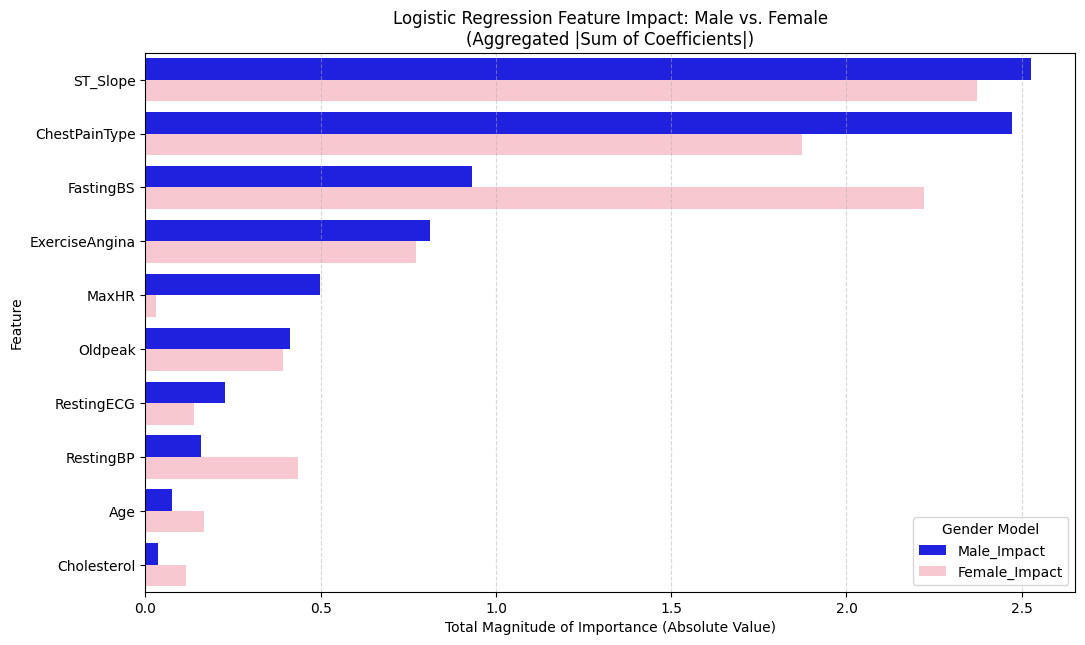

In [10]:
#Feature Importance - Gender wise - Logistic Regression
X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

LogisticRegression_male = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_male.fit(X_male, y_male)

LogisticRegression_female = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_female.fit(X_female, y_female)

raw_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Male_Coef': LogisticRegression_male.coef_[0],
    'Female_Coef': LogisticRegression_female.coef_[0]
})

cat_prefixes = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

male_agg = {}
female_agg = {}

for index, row in raw_importance_df.iterrows():
    feature_name = row['Feature']
    parent_feature = feature_name 
    
    
    for prefix in cat_prefixes:
        if feature_name.startswith(prefix + '_'):
            parent_feature = prefix
            break
    
    
    male_agg[parent_feature] = male_agg.get(parent_feature, 0) + abs(row['Male_Coef'])
    female_agg[parent_feature] = female_agg.get(parent_feature, 0) + abs(row['Female_Coef'])


grouped_df = pd.DataFrame({
    'Feature': male_agg.keys(),
    'Male_Impact': male_agg.values(),
    'Female_Impact': [female_agg[k] for k in male_agg.keys()]
})

grouped_df = grouped_df[grouped_df['Feature'] != 'Sex']

grouped_df = grouped_df.sort_values(by='Male_Impact', ascending=False)
plot_data = grouped_df.melt(id_vars='Feature', var_name='Gender', value_name='Impact')

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data, 
    x='Impact', 
    y='Feature', 
    hue='Gender', 
    palette={'Male_Impact': 'blue', 'Female_Impact': 'pink'}
)

plt.title('Logistic Regression Feature Impact: Male vs. Female\n(Aggregated |Sum of Coefficients|)')
plt.xlabel('Total Magnitude of Importance (Absolute Value)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Gender Model')
plt.show()


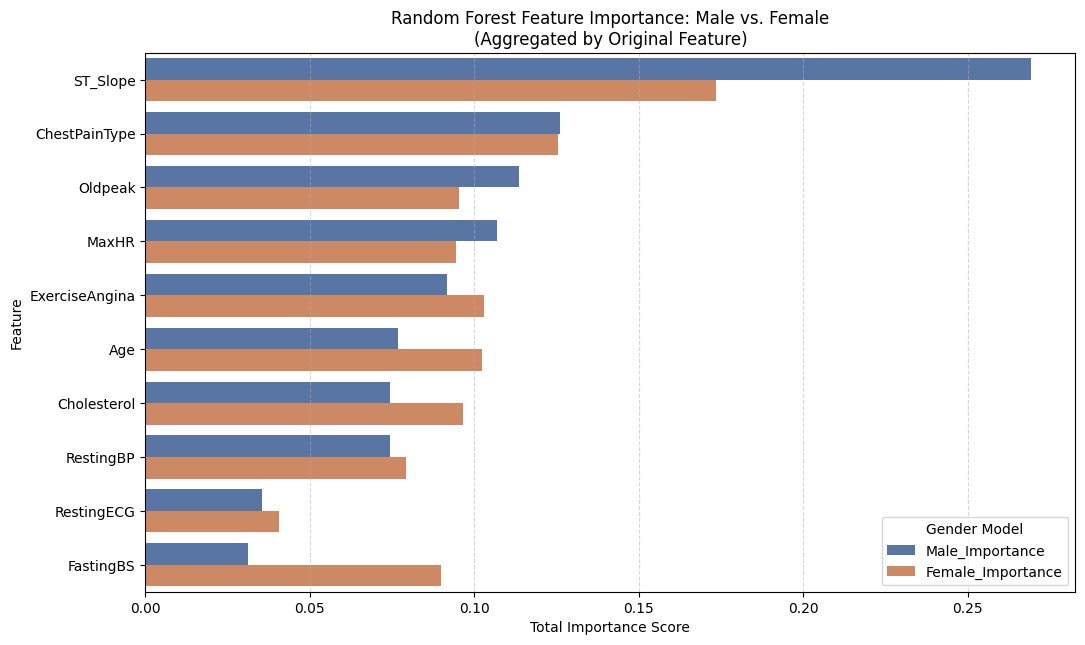

In [11]:
#Feature Importance - Gender wise - Random Forest

X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

model_male = RandomForestClassifier(n_estimators=100, random_state=42)
model_male.fit(X_male, y_male)

model_female = RandomForestClassifier(n_estimators=100, random_state=42)
model_female.fit(X_female, y_female)

raw_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Male_Raw': model_male.feature_importances_,
    'Female_Raw': model_female.feature_importances_
})

#Define the Original Categorical Groups 
cat_prefixes = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

male_agg = {}
female_agg = {}

for index, row in raw_importance_df.iterrows():
    feature_name = row['Feature']
    parent_feature = feature_name
    
    for prefix in cat_prefixes:
        if feature_name.startswith(prefix + '_'):
            parent_feature = prefix
            break
    
    male_agg[parent_feature] = male_agg.get(parent_feature, 0) + row['Male_Raw']
    female_agg[parent_feature] = female_agg.get(parent_feature, 0) + row['Female_Raw']

grouped_df = pd.DataFrame({
    'Feature': male_agg.keys(),
    'Male_Importance': male_agg.values(),
    'Female_Importance': [female_agg[k] for k in male_agg.keys()]
})

grouped_df = grouped_df[grouped_df['Feature'] != 'Sex']

grouped_df = grouped_df.sort_values(by='Male_Importance', ascending=False)
plot_data = grouped_df.melt(id_vars='Feature', var_name='Gender', value_name='Importance')


plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data, 
    x='Importance', 
    y='Feature', 
    hue='Gender', 
    palette={'Male_Importance': '#4C72B0', 'Female_Importance': '#DD8452'} # Blue vs Orange
)

plt.title('Random Forest Feature Importance: Male vs. Female\n(Aggregated by Original Feature)')
plt.xlabel('Total Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Gender Model')
plt.show()


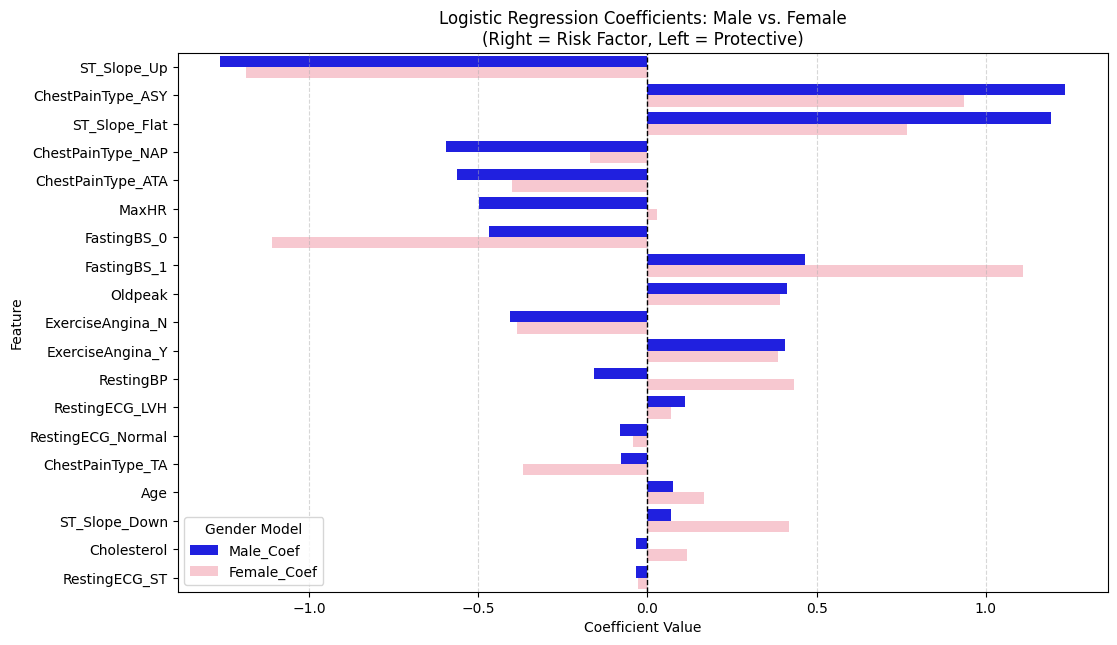

Top 10 Features by Gender Coefficients:
              Feature  Male_Coef  Female_Coef
18        ST_Slope_Up  -1.264097    -1.186364
8   ChestPainType_ASY   1.235140     0.937022
17      ST_Slope_Flat   1.193845     0.768014
10  ChestPainType_NAP  -0.596020    -0.170121
9   ChestPainType_ATA  -0.561735    -0.399852
3               MaxHR  -0.499270     0.029521
14        FastingBS_0  -0.466862    -1.110396
15        FastingBS_1   0.465347     1.110067
4             Oldpeak   0.412478     0.392649
12   ExerciseAngina_N  -0.406855    -0.385557


In [12]:
#Sub-feature importance gender wise - Logistic regression
X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

LogisticRegression_male = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_male.fit(X_male, y_male)

LogisticRegression_female = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_female.fit(X_female, y_female)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Male_Coef': LogisticRegression_male.coef_[0],
    'Female_Coef': LogisticRegression_female.coef_[0],
    'Abs_Male_Coef': abs(LogisticRegression_male.coef_[0]) # Used for sorting
})
importance_df = importance_df[~importance_df['Feature'].str.startswith('Sex')]

importance_df = importance_df.sort_values(by='Abs_Male_Coef', ascending=False)

plot_data = importance_df.head(100).melt(
    id_vars='Feature', 
    value_vars=['Male_Coef', 'Female_Coef'], 
    var_name='Gender', 
    value_name='Coefficient'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data, 
    x='Coefficient', 
    y='Feature', 
    hue='Gender', 
    palette={'Male_Coef': 'blue', 'Female_Coef': 'pink'}
)

plt.title('Logistic Regression Coefficients: Male vs. Female\n(Right = Risk Factor, Left = Protective)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Gender Model')
plt.show()

print("Top 10 Features by Gender Coefficients:")
print(importance_df[['Feature', 'Male_Coef', 'Female_Coef']].head(10))

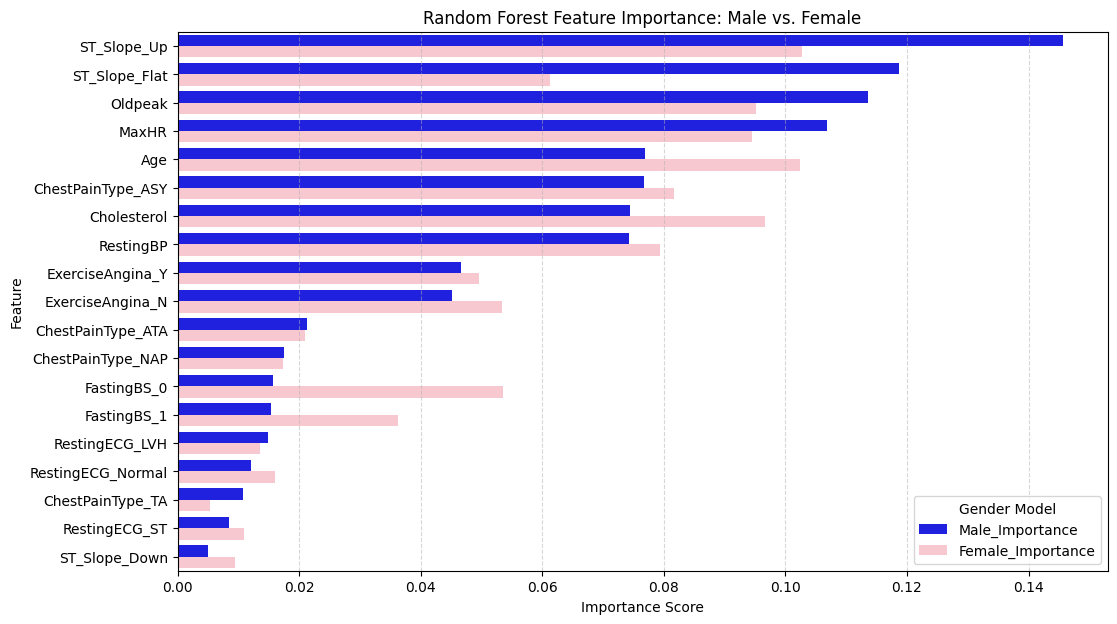

Top 10 Features by Gender Importance:
              Feature  Male_Importance  Female_Importance
18        ST_Slope_Up         0.145710           0.102807
17      ST_Slope_Flat         0.118627           0.061229
4             Oldpeak         0.113627           0.095208
3               MaxHR         0.106851           0.094468
0                 Age         0.076857           0.102341
8   ChestPainType_ASY         0.076764           0.081756
2         Cholesterol         0.074484           0.096581
1           RestingBP         0.074298           0.079297
13   ExerciseAngina_Y         0.046656           0.049638
12   ExerciseAngina_N         0.045192           0.053323


In [13]:
#Sub-feature importance gender wise - Random Forest

X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

model_male = RandomForestClassifier(n_estimators=100, random_state=42)
model_male.fit(X_male, y_male)

model_female = RandomForestClassifier(n_estimators=100, random_state=42)
model_female.fit(X_female, y_female)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Male_Importance': model_male.feature_importances_,
    'Female_Importance': model_female.feature_importances_
})

importance_df = importance_df[~importance_df['Feature'].str.startswith('Sex')]

importance_df = importance_df.sort_values(by='Male_Importance', ascending=False)

plot_data = importance_df.head(100).melt(id_vars='Feature', var_name='Gender', value_name='Importance')

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_data, x='Importance', y='Feature', hue='Gender', palette={'Male_Importance': 'blue', 'Female_Importance': 'pink'})

plt.title('Random Forest Feature Importance: Male vs. Female')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Gender Model')
plt.show()

print("Top 10 Features by Gender Importance:")
print(importance_df.head(10))

# Bias Mitigation


### Random Sampling

In [14]:
X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

count_male = len(X_male)
count_female = len(X_female)
n_to_add = count_male - count_female

print(f"--- Original Training Data ---")
print(f"Men: {count_male}")
print(f"Women: {count_female}")
print(f"Gap: {n_to_add} missing female samples.")

if n_to_add > 0:
    print(f"\nGenerating {n_to_add} synthetic female samples...")
    
    synthetic_X = X_female.sample(n=n_to_add, replace=True, random_state=42)
    synthetic_y = y_female.loc[synthetic_X.index] 

    numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
    
    # Add 5% random noise to the numerical columns to create realistic variety
    for col in numerical_cols:
        if col in synthetic_X.columns:
            std_dev = synthetic_X[col].std()
            # Noise = Random value centered at 0, with a spread of 5% of the column's std dev
            noise = np.random.normal(0, std_dev * 0.05, size=len(synthetic_X))
            synthetic_X[col] = synthetic_X[col] + noise

    X_train_balanced = pd.concat([X_train, synthetic_X], axis=0)
    y_train_balanced = pd.concat([y_train, synthetic_y], axis=0)
    
    print(f"Done. New Training Count: {len(X_train_balanced)} rows.")

else:
    print("\nData is already balanced. No synthetic data needed.")
    X_train_balanced = X_train
    y_train_balanced = y_train


--- Original Training Data ---
Men: 579
Women: 155
Gap: 424 missing female samples.

Generating 424 synthetic female samples...
Done. New Training Count: 1158 rows.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score

# Initialize models
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
lr.fit(X_train_balanced, y_train_balanced)
rf.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)



In [16]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def evaluate_group(model_name, y_true, y_pred, mask, group_name):
    print(f"\n--- {model_name} | {group_name} ---")
    print("Accuracy:", accuracy_score(y_true[mask], y_pred[mask]))
    print("Recall:", recall_score(y_true[mask], y_pred[mask]))
    print("Precision:", precision_score(y_true[mask], y_pred[mask], zero_division=0))
    print("F1-score:", f1_score(y_true[mask], y_pred[mask]))

# Create masks
male_mask = X_test["Sex_M"] == 1
female_mask = X_test["Sex_M"] == 0


# ===== Logistic Regression =====
print("=== Logistic Regression (Overall) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

evaluate_group("Logistic Regression", y_test, y_pred_lr, male_mask, "Male")
evaluate_group("Logistic Regression", y_test, y_pred_lr, female_mask, "Female")


# ===== Random Forest =====
print("\n=== Random Forest (Overall) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

evaluate_group("Random Forest", y_test, y_pred_rf, male_mask, "Male")
evaluate_group("Random Forest", y_test, y_pred_rf, female_mask, "Female")

=== Logistic Regression (Overall) ===
Accuracy: 0.8804347826086957
Recall: 0.9019607843137255
Precision: 0.8846153846153846
F1-score: 0.8932038834951457

--- Logistic Regression | Male ---
Accuracy: 0.8835616438356164
Recall: 0.9166666666666666
Precision: 0.9072164948453608
F1-score: 0.9119170984455959

--- Logistic Regression | Female ---
Accuracy: 0.868421052631579
Recall: 0.6666666666666666
Precision: 0.5714285714285714
F1-score: 0.6153846153846154

=== Random Forest (Overall) ===
Accuracy: 0.8804347826086957
Recall: 0.9019607843137255
Precision: 0.8846153846153846
F1-score: 0.8932038834951457

--- Random Forest | Male ---
Accuracy: 0.8698630136986302
Recall: 0.9166666666666666
Precision: 0.8888888888888888
F1-score: 0.9025641025641026

--- Random Forest | Female ---
Accuracy: 0.9210526315789473
Recall: 0.6666666666666666
Precision: 0.8
F1-score: 0.7272727272727273


### SMOTE

In [19]:
pip install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from imblearn.over_sampling import SMOTE
import pandas as pd

sex_col = [col for col in X_train.columns if col.startswith("Sex_")][1]

X_male = X_train[X_train[sex_col] == True]
y_male = y_train.loc[X_male.index]

X_female = X_train[X_train[sex_col] == False]
y_female = y_train.loc[X_female.index]

print("--- Original Distribution ---")
print("\nFemale target distribution:")
print(y_female.value_counts())

print("\nMale target distribution:")
print(y_male.value_counts())


smote = SMOTE(random_state=42, k_neighbors=5)

X_female_smote, y_female_smote = smote.fit_resample(X_female, y_female)

print("\n--- After SMOTE (Female Only) ---")
print(pd.Series(y_female_smote).value_counts())

X_train_balanced = pd.concat([X_male, pd.DataFrame(X_female_smote, columns=X_female.columns)], axis=0)
y_train_balanced = pd.concat([y_male, pd.Series(y_female_smote)], axis=0)

X_train_balanced = X_train_balanced.reset_index(drop=True)
y_train_balanced = y_train_balanced.reset_index(drop=True)

shuffled_idx = X_train_balanced.sample(frac=1, random_state=42).index

X_train_balanced = X_train_balanced.loc[shuffled_idx].reset_index(drop=True)
y_train_balanced = y_train_balanced.loc[shuffled_idx].reset_index(drop=True)

print("\n--- Final Combined Distribution ---")
print(y_train_balanced.value_counts())

print(f"\nFinal Training Size: {len(X_train_balanced)}")

--- Original Distribution ---

Female target distribution:
HeartDisease
0    111
1     44
Name: count, dtype: int64

Male target distribution:
HeartDisease
1    362
0    217
Name: count, dtype: int64

--- After SMOTE (Female Only) ---
HeartDisease
1    111
0    111
Name: count, dtype: int64

--- Final Combined Distribution ---
HeartDisease
1    473
0    328
Name: count, dtype: int64

Final Training Size: 801


In [21]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train_balanced, y_train_balanced)
rf.fit(X_train_balanced, y_train_balanced)


X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_test_df = pd.DataFrame(X_test, columns=X_train.columns)

male_col = 'Sex_M'  # encoded gender column

# Split test data
male_mask = X_test_df[male_col] == 1

X_test_male = X_test_df[male_mask]
X_test_female = X_test_df[~male_mask]

y_test_male = y_test[male_mask]
y_test_female = y_test[~male_mask]


def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]


results = pd.DataFrame([
    ["LR_Male", *evaluate(y_test_male, lr.predict(X_test_male))],
    ["LR_Female", *evaluate(y_test_female, lr.predict(X_test_female))],
    ["RF_Male", *evaluate(y_test_male, rf.predict(X_test_male))],
    ["RF_Female", *evaluate(y_test_female, rf.predict(X_test_female))]
],
columns=["Group", "Accuracy", "Precision", "Recall", "F1"])

print("\n--- Gender-wise Model Performance (Female-SMOTE) ---")
print(results)


--- Gender-wise Model Performance (Female-SMOTE) ---
       Group  Accuracy  Precision    Recall        F1
0    LR_Male  0.897260   0.917526  0.927083  0.922280
1  LR_Female  0.894737   0.625000  0.833333  0.714286
2    RF_Male  0.869863   0.881188  0.927083  0.903553
3  RF_Female  0.921053   0.714286  0.833333  0.769231


In [22]:
pushing_cols = [c for c in X_train_balanced.columns
                if c in ['Age', 'Cholesterol']
                or c.startswith('ST_Slope')
                or c.startswith('FastingBS')]


if 'FastingBS' not in pushing_cols and 'FastingBS' in X_train_balanced.columns:
    pushing_cols = ['FastingBS'] + pushing_cols

top4_cols = [c for c in X_train_balanced.columns
             if c in ['FastingBS']
             or c.startswith('ChestPainType')
             or c.startswith('ExerciseAngina')
             or c.startswith('ST_Slope')]

X_train_p = X_train_balanced[pushing_cols]
X_test_p  = X_test.reindex(columns=pushing_cols, fill_value=0)

X_train_t = X_train_balanced[top4_cols]
X_test_t  = X_test.reindex(columns=top4_cols, fill_value=0)

lr_p = LogisticRegression(max_iter=2000, random_state=42)
rf_p = RandomForestClassifier(random_state=42)

lr_t = LogisticRegression(max_iter=2000, random_state=42)
rf_t = RandomForestClassifier(random_state=42)

lr_p.fit(X_train_p, y_train_balanced)
rf_p.fit(X_train_p, y_train_balanced)

lr_t.fit(X_train_t, y_train_balanced)
rf_t.fit(X_train_t, y_train_balanced)

X_test   = X_test.reset_index(drop=True)
X_test_p = X_test_p.reset_index(drop=True)
X_test_t = X_test_t.reset_index(drop=True)
y_test   = y_test.reset_index(drop=True)

male_mask = (X_test['Sex_M'] == 1).values

X_test_p_male   = X_test_p[male_mask]
X_test_p_female = X_test_p[~male_mask]

X_test_t_male   = X_test_t[male_mask]
X_test_t_female = X_test_t[~male_mask]

y_test_male   = y_test[male_mask]
y_test_female = y_test[~male_mask]


def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

results = pd.DataFrame([
    ["Pushing4_LR_Male",   *evaluate(y_test_male,   lr_p.predict(X_test_p_male))],
    ["Pushing4_LR_Female", *evaluate(y_test_female, lr_p.predict(X_test_p_female))],
    ["Pushing4_RF_Male",   *evaluate(y_test_male,   rf_p.predict(X_test_p_male))],
    ["Pushing4_RF_Female", *evaluate(y_test_female, rf_p.predict(X_test_p_female))],

    ["Top4_LR_Male",       *evaluate(y_test_male,   lr_t.predict(X_test_t_male))],
    ["Top4_LR_Female",     *evaluate(y_test_female, lr_t.predict(X_test_t_female))],
    ["Top4_RF_Male",       *evaluate(y_test_male,   rf_t.predict(X_test_t_male))],
    ["Top4_RF_Female",     *evaluate(y_test_female, rf_t.predict(X_test_t_female))],
],
columns=["Group", "Accuracy", "Precision", "Recall", "F1"])

print("\n--- Pushing-4 & Top-4 (Female-SMOTE) ---")
print(results.to_string(index=False))


--- Pushing-4 & Top-4 (Female-SMOTE) ---
             Group  Accuracy  Precision   Recall       F1
  Pushing4_LR_Male  0.773973   0.862069 0.781250 0.819672
Pushing4_LR_Female  0.684211   0.312500 0.833333 0.454545
  Pushing4_RF_Male  0.801370   0.852632 0.843750 0.848168
Pushing4_RF_Female  0.631579   0.277778 0.833333 0.416667
      Top4_LR_Male  0.842466   0.884211 0.875000 0.879581
    Top4_LR_Female  0.736842   0.375000 1.000000 0.545455
      Top4_RF_Male  0.842466   0.884211 0.875000 0.879581
    Top4_RF_Female  0.736842   0.375000 1.000000 0.545455


### Fairness Aware Reweighting

In [23]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score

# Masks
female_mask = X_test['Sex_F'] == 1
male_mask   = X_test['Sex_F'] == 0


lr_base = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

rf_base = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

lr_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

y_pred_lr_base = lr_base.predict(X_test)
y_pred_rf_base = rf_base.predict(X_test)

# Female Recall
lr_base_recall_female = recall_score(y_test[female_mask], y_pred_lr_base[female_mask])
rf_base_recall_female = recall_score(y_test[female_mask], y_pred_rf_base[female_mask])

# Male Recall
lr_base_recall_male = recall_score(y_test[male_mask], y_pred_lr_base[male_mask])
rf_base_recall_male = recall_score(y_test[male_mask], y_pred_rf_base[male_mask])


print("WEIGHTED MODELS (Female Boost)")

sample_weight = np.ones(len(y_train))
boost_factor = 3

mask = (X_train['Sex_F'] == 1) & (y_train == 1)
sample_weight[mask] = boost_factor

print("Boosted Female + Disease samples:", mask.sum())

lr_weighted = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

rf_weighted = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

lr_weighted.fit(X_train, y_train, sample_weight=sample_weight)
rf_weighted.fit(X_train, y_train, sample_weight=sample_weight)

y_pred_lr_weighted = lr_weighted.predict(X_test)
y_pred_rf_weighted = rf_weighted.predict(X_test)

# Female Recall
lr_weighted_recall_female = recall_score(y_test[female_mask], y_pred_lr_weighted[female_mask])
rf_weighted_recall_female = recall_score(y_test[female_mask], y_pred_rf_weighted[female_mask])

# Male Recall
lr_weighted_recall_male = recall_score(y_test[male_mask], y_pred_lr_weighted[male_mask])
rf_weighted_recall_male = recall_score(y_test[male_mask], y_pred_rf_weighted[male_mask])


print("RECALL COMPARISON (FEMALE vs MALE)")

print(f"Logistic Regression Female Recall: AFTER = {lr_weighted_recall_female:.4f}")
print(f"Logistic Regression Male Recall: AFTER = {lr_weighted_recall_male:.4f}")

print(f"\nRandom Forest Female Recall: AFTER = {rf_weighted_recall_female:.4f}")
print(f"Random Forest Male Recall:  AFTER = {rf_weighted_recall_male:.4f}")

WEIGHTED MODELS (Female Boost)
Boosted Female + Disease samples: 44
RECALL COMPARISON (FEMALE vs MALE)
Logistic Regression Female Recall: AFTER = 0.8333
Logistic Regression Male Recall: AFTER = 0.8854

Random Forest Female Recall: AFTER = 0.8333
Random Forest Male Recall:  AFTER = 0.9167


In [24]:
# Separate datasets
df_female = df[df['Sex'] == 'F'].copy()
df_male   = df[df['Sex'] == 'M'].copy()

print("Female shape:", df_female.shape)
print("Male shape:", df_male.shape)

Female shape: (193, 12)
Male shape: (725, 12)


In [25]:
X_f = df_female.drop(columns=['HeartDisease','Sex'])
y_f = df_female['HeartDisease']

X_m = df_male.drop(columns=['HeartDisease','Sex'])
y_m = df_male['HeartDisease']

In [26]:
X_f = pd.get_dummies(X_f, drop_first=True)
X_m = pd.get_dummies(X_m, drop_first=True)

# Align columns (important!)
X_f, X_m = X_f.align(X_m, join='outer', axis=1, fill_value=0)

In [27]:
from sklearn.model_selection import train_test_split

def train_model(X, y, model):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    model.fit(X_train, y_train)
    
    return model, X_train, X_test, y_train, y_test

In [28]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42
)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [29]:
# Female models
rf_f, X_train_f, X_test_f, y_train_f, y_test_f = train_model(X_f, y_f, rf)
lr_f, _, _, _, _ = train_model(X_f, y_f, lr)

# Male models
rf_m, X_train_m, X_test_m, y_train_m, y_test_m = train_model(X_m, y_m, rf)
lr_m, _, _, _, _ = train_model(X_m, y_m, lr)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
import numpy as np

# Define scorers
recall_scorer = make_scorer(recall_score)
accuracy_scorer = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score)
f1_scorer = make_scorer(f1_score)

print("===== Logistic Regression - Female Only Full Model =====")

cv_recall_lr = cross_val_score(lr, X_f, y_f, cv=5, scoring=recall_scorer)
cv_acc_lr = cross_val_score(lr, X_f, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_lr = cross_val_score(lr, X_f, y_f, cv=5, scoring=precision_scorer)
cv_f1_lr = cross_val_score(lr, X_f, y_f, cv=5, scoring=f1_scorer)

print("Recall Mean:", np.mean(cv_recall_lr), "Std:", np.std(cv_recall_lr))
print("Precision Mean:", np.mean(cv_prec_lr), "Std:", np.std(cv_prec_lr))
print("Accuracy Mean:", np.mean(cv_acc_lr), "Std:", np.std(cv_acc_lr))
print("F1 Mean:", np.mean(cv_f1_lr), "Std:", np.std(cv_f1_lr))


print("\n===== Random Forest - Female Only Full Model =====")

cv_recall_rf = cross_val_score(rf, X_f, y_f, cv=5, scoring=recall_scorer)
cv_acc_rf = cross_val_score(rf, X_f, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_rf = cross_val_score(rf, X_f, y_f, cv=5, scoring=precision_scorer)
cv_f1_rf = cross_val_score(rf, X_f, y_f, cv=5, scoring=f1_scorer)

print("Recall Mean:", np.mean(cv_recall_rf), "Std:", np.std(cv_recall_rf))
print("Precision Mean:", np.mean(cv_prec_rf), "Std:", np.std(cv_prec_rf))
print("Accuracy Mean:", np.mean(cv_acc_rf), "Std:", np.std(cv_acc_rf))
print("F1 Mean:", np.mean(cv_f1_rf), "Std:", np.std(cv_f1_rf))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


===== Logistic Regression - Female Only Full Model =====


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

Recall Mean: 0.74 Std: 0.12000000000000002
Precision Mean: 0.5897435897435898 Std: 0.0778841567058549
Accuracy Mean: 0.7873144399460189 Std: 0.042984945385393034
F1 Mean: 0.6436138655818289 Std: 0.03502075379565854

===== Random Forest - Female Only Full Model =====
Recall Mean: 0.4999999999999999 Std: 0.2449489742783178
Precision Mean: 0.5988888888888889 Std: 0.22932132828182003
Accuracy Mean: 0.7979757085020243 Std: 0.08726718326038606
F1 Mean: 0.5394486215538847 Std: 0.24341308603134368


#### 3- Metabolic Model

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define models
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score,f1_score
import numpy as np

# Female subset
df_female = df[df['Sex'] == 'F'].copy()

X_meta = df_female[['Age', 'Cholesterol', 'FastingBS']]
y_f = df_female['HeartDisease']

# Define scorers
recall_scorer = make_scorer(recall_score)
accuracy_scorer = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score)
f1_scorer = make_scorer(f1_score)


cv_recall_lr = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=recall_scorer)
cv_acc_lr = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_lr = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=precision_scorer)
cv_f1_lr = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=f1_scorer)

print("Metabolic Model - Logistic Regression (Female)")
print("Recall Mean:", np.mean(cv_recall_lr), "Std:", np.std(cv_recall_lr))
print("Precision Mean:", np.mean(cv_prec_lr), "Std:", np.std(cv_prec_lr))
print("Accuracy Mean:", np.mean(cv_acc_lr), "Std:", np.std(cv_acc_lr))
print("F1 Mean:", np.mean(cv_f1_lr), "Std:", np.std(cv_f1_lr))


cv_recall_rf = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=recall_scorer)
cv_acc_rf = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_rf = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=precision_scorer)
cv_f1_rf = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=f1_scorer)

print("\n3-Metabolic Model - Random Forest (Female)")
print("Recall Mean:", np.mean(cv_recall_rf), "Std:", np.std(cv_recall_rf))
print("Precision Mean:", np.mean(cv_prec_rf), "Std:", np.std(cv_prec_rf))
print("Accuracy Mean:", np.mean(cv_acc_rf), "Std:", np.std(cv_acc_rf))
print("F1 Mean:", np.mean(cv_f1_rf), "Std:", np.std(cv_f1_rf))

Metabolic Model - Logistic Regression (Female)
Recall Mean: 0.26 Std: 0.14966629547095767
Precision Mean: 0.7333333333333333 Std: 0.24381231397212985
Accuracy Mean: 0.7616734143049932 Std: 0.044091363417618004
F1 Mean: 0.33862803862803864 Std: 0.13475435236537928

3-Metabolic Model - Random Forest (Female)
Recall Mean: 0.34 Std: 0.12
Precision Mean: 0.5727272727272728 Std: 0.24400996532360478
Accuracy Mean: 0.7199730094466936 Std: 0.06113524171628241
F1 Mean: 0.3771228771228771 Std: 0.06638292941549227


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
import numpy as np

X_meta = df[['Age', 'Cholesterol', 'FastingBS']]
y = df['HeartDisease']

# Define scorers
recall_scorer = make_scorer(recall_score)
accuracy_scorer = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score)
f1_scorer = make_scorer(f1_score)



cv_recall_lr = cross_val_score(model_lr, X_meta, y, cv=5, scoring=recall_scorer)
cv_acc_lr = cross_val_score(model_lr, X_meta, y, cv=5, scoring=accuracy_scorer)
cv_prec_lr = cross_val_score(model_lr, X_meta, y, cv=5, scoring=precision_scorer)
cv_f1_lr = cross_val_score(model_lr, X_meta, y, cv=5, scoring=f1_scorer)    

print("Metabolic Model - Logistic Regression (Full Dataset)")
print("Recall Mean:", np.mean(cv_recall_lr), "Std:", np.std(cv_recall_lr))
print("Precision Mean:", np.mean(cv_prec_lr), "Std:", np.std(cv_prec_lr))
print("Accuracy Mean:", np.mean(cv_acc_lr), "Std:", np.std(cv_acc_lr))
print("F1 Mean:", np.mean(cv_f1_lr), "Std:", np.std(cv_f1_lr))



cv_recall_rf = cross_val_score(model_rf, X_meta, y, cv=5, scoring=recall_scorer)
cv_acc_rf = cross_val_score(model_rf, X_meta, y, cv=5, scoring=accuracy_scorer)
cv_prec_rf = cross_val_score(model_rf, X_meta, y, cv=5, scoring=precision_scorer)
cv_f1_rf = cross_val_score(model_rf, X_meta, y, cv=5, scoring=f1_scorer)

print("\nMetabolic Model - Random Forest (Full Dataset)")
print("Recall Mean:", np.mean(cv_recall_rf), "Std:", np.std(cv_recall_rf))
print("Precision Mean:", np.mean(cv_prec_rf), "Std:", np.std(cv_prec_rf))
print("Accuracy Mean:", np.mean(cv_acc_rf), "Std:", np.std(cv_acc_rf))
print("F1 Mean:", np.mean(cv_f1_rf), "Std:", np.std(cv_f1_rf))

Metabolic Model - Logistic Regression (Full Dataset)
Recall Mean: 0.7050669772859639 Std: 0.24000660512956787
Precision Mean: 0.691051413346372 Std: 0.04537282810304862
Accuracy Mean: 0.6557911617961512 Std: 0.07434243491555705
F1 Mean: 0.6677794264741393 Std: 0.1547212332892299

Metabolic Model - Random Forest (Full Dataset)
Recall Mean: 0.6238012036497768 Std: 0.1718570147146956
Precision Mean: 0.6428570723096414 Std: 0.02776916415167749
Accuracy Mean: 0.5968876217628891 Std: 0.04173682547603206
F1 Mean: 0.6187374834417467 Std: 0.09166228475631893


### 4. Feature model


In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import pandas as pd
import numpy as np

# Select features
X_selected = df[['Age', 'Cholesterol', 'FastingBS', 'ST_Slope']].copy() #Pushing features
X_selected2 = df[['ChestPainType', 'FastingBS', 'ExerciseAngina', 'ST_Slope']].copy() #top4
X_selected3 = df[['Age', 'Cholesterol', 'FastingBS']].copy()
y = df['HeartDisease']

# One-hot encode ST_Slope
X_selected = pd.get_dummies(X_selected, columns=['ST_Slope'], drop_first=True)
X_selected2 = pd.get_dummies(X_selected2, columns=['ChestPainType','ExerciseAngina','ST_Slope'], drop_first=True)

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [ ]:
#Pushing 4 - Female only Dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    female_recalls = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected, y):
        
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        recall = recall_score(
            y_test[female_mask],
            y_pred[female_mask]
        )

        accuracy = accuracy_score(
            y_test[female_mask],
            y_pred[female_mask]
        )
        
        female_recalls.append(recall)
        female_accuracy.append(accuracy)
    
    print(f"\n{name} - 4-Pushing Feature Model (Female)")
    print("Mean Recall:", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    print("Std:", np.std(female_recalls))


Logistic Regression - 4-Pushing Feature Model (Female)
Mean Recall: 0.8868686868686868
Mean Accuracy: 0.7593162155085977
Std: 0.08861297858368204

Random Forest - 4-Pushing Feature Model (Female)
Mean Recall: 0.8868686868686868
Mean Accuracy: 0.745938403304318
Std: 0.10563164818102118


In [ ]:
#Pushing 4 - Pooled Dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    recalls = []
    accuracy_pooled = []
    
    for train_idx, test_idx in skf.split(X_selected, y):
        
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        recall = recall_score(y_test, y_pred)
            #y_test[female_mask],
            #y_pred[female_mask]
        

        accuracy = accuracy_score(y_test, y_pred)
            #y_test[female_mask],
            #y_pred[female_mask]
        
        
        recalls.append(recall)
        accuracy_pooled.append(accuracy)
    
    print(f"\n{name} - Pushing 4-Feature Model (Pooled)")
    print("Mean Recall:", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    print("Std:", np.std(female_recalls))


Logistic Regression - Pushing 4-Feature Model (Pooled)
Mean Recall: 0.8868686868686868
Mean Accuracy: 0.745938403304318
Std: 0.10563164818102118

Random Forest - Pushing 4-Feature Model (Pooled)
Mean Recall: 0.8868686868686868
Mean Accuracy: 0.745938403304318
Std: 0.10563164818102118


In [ ]:
#male and female - Pushing 4 model

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    male_recalls = []
    female_recalls = []
    
    male_accuracy = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected, y):
        
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Masks for gender
        male_mask = df.iloc[test_idx]['Sex'] == 'M'
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        # Male metrics
        male_recall = recall_score(y_test[male_mask], y_pred[male_mask])
        male_acc = accuracy_score(y_test[male_mask], y_pred[male_mask])
        
        # Female metrics
        female_recall = recall_score(y_test[female_mask], y_pred[female_mask])
        female_acc = accuracy_score(y_test[female_mask], y_pred[female_mask])
        
        male_recalls.append(male_recall)
        female_recalls.append(female_recall)
        
        male_accuracy.append(male_acc)
        female_accuracy.append(female_acc)
    
    print(f"\n{name} - Pushing 4 Feature Model - Age,Cholesterol,FastingBS,ST_Slope")
    
    print("\nMale Results")
    print("Mean Recall:", np.mean(male_recalls))
    print("Mean Accuracy:", np.mean(male_accuracy))
    
    print("\nFemale Results")
    print("Mean Recall:", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    
    print("\nRecall Std Dev (Female):", np.std(female_recalls))


Logistic Regression - Pushing 4 Feature Model - Age,Cholesterol,FastingBS,ST_Slope

Male Results
Mean Recall: 0.8600054456996954
Mean Accuracy: 0.8327564751889597

Female Results
Mean Recall: 0.8868686868686868
Mean Accuracy: 0.7593162155085977

Recall Std Dev (Female): 0.08861297858368204

Random Forest - Pushing 4 Feature Model - Age,Cholesterol,FastingBS,ST_Slope

Male Results
Mean Recall: 0.8296387343371917
Mean Accuracy: 0.7917726411753762

Female Results
Mean Recall: 0.8868686868686868
Mean Accuracy: 0.745938403304318

Recall Std Dev (Female): 0.10563164818102118


In [ ]:
# Female - Top 4 features

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    female_recalls = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected2, y):
        
        X_train, X_test = X_selected2.iloc[train_idx], X_selected2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        recall = recall_score(
            y_test[female_mask],
            y_pred[female_mask]
        )

        accuracy = accuracy_score(
            y_test[female_mask],
            y_pred[female_mask]
        )
        
        female_recalls.append(recall)
        female_accuracy.append(accuracy)
    
    print(f"\n{name} - Top 4-Feature Model (Female)")
    print("Mean Recall:", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    print("Std:", np.std(female_recalls))


Logistic Regression - Top 4-Feature Model (Female)
Mean Recall: 0.8368686868686869
Mean Accuracy: 0.8517691898722685
Std: 0.08086487902878961

Random Forest - Top 4-Feature Model (Female)
Mean Recall: 0.8005050505050505
Mean Accuracy: 0.8215002717984723
Std: 0.1407089197671221


In [ ]:
#Top 4 - Pooled Dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    recalls = []
    accuracy_pooled = []
    
    for train_idx, test_idx in skf.split(X_selected2, y):
        
        X_train, X_test = X_selected2.iloc[train_idx], X_selected2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        #female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        recall = recall_score(y_test, y_pred)
            #y_test[female_mask],
            #y_pred[female_mask]
        

        accuracy = accuracy_score(y_test, y_pred)
            #y_test[female_mask],
            #y_pred[female_mask]
        
        
        recalls.append(recall)
        accuracy_pooled.append(accuracy)
    
    print(f"\n{name} - Top 4-Feature Model (Pooled)")
    print("Mean Recall:", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    print("Std:", np.std(female_recalls))


Logistic Regression - Top 4-Feature Model (Pooled)
Mean Recall: 0.8005050505050505
Mean Accuracy: 0.8215002717984723
Std: 0.1407089197671221

Random Forest - Top 4-Feature Model (Pooled)
Mean Recall: 0.8005050505050505
Mean Accuracy: 0.8215002717984723
Std: 0.1407089197671221


In [44]:
# Male & Female - Top 4 new features


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    male_recalls = []
    female_recalls = []
    
    male_accuracy = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected2, y):
        
        X_train, X_test = X_selected2.iloc[train_idx], X_selected2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Gender masks
        male_mask = df.iloc[test_idx]['Sex'] == 'M'
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        # Male metrics
        male_recall = recall_score(
            y_test[male_mask],
            y_pred[male_mask]
        )

        male_acc = accuracy_score(
            y_test[male_mask],
            y_pred[male_mask]
        )
        
        # Female metrics
        female_recall = recall_score(
            y_test[female_mask],
            y_pred[female_mask]
        )

        female_acc = accuracy_score(
            y_test[female_mask],
            y_pred[female_mask]
        )
        
        male_recalls.append(male_recall)
        female_recalls.append(female_recall)
        
        male_accuracy.append(male_acc)
        female_accuracy.append(female_acc)
    
    print(f"\n{name} - Top 4 Feature Model")
    
    print("\nMale Results")
    print("Mean Recall:", np.mean(male_recalls))
    print("Mean Accuracy:", np.mean(male_accuracy))
    
    print("\nFemale Results")
    print("Mean Recall:", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    
    print("\nFemale Recall Std:", np.std(female_recalls))


Logistic Regression - Top 4 Feature Model

Male Results
Mean Recall: 0.8841817836207738
Mean Accuracy: 0.8543142453113306

Female Results
Mean Recall: 0.8368686868686869
Mean Accuracy: 0.8517691898722685

Female Recall Std: 0.08086487902878961

Random Forest - Top 4 Feature Model

Male Results
Mean Recall: 0.8797861792251694
Mean Accuracy: 0.8445206560664452

Female Results
Mean Recall: 0.8005050505050505
Mean Accuracy: 0.8215002717984723

Female Recall Std: 0.1407089197671221
